In [105]:

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sklearn.datasets import  load_files
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings(action='ignore')


In [106]:
%cd D:/du_lieu_huan_luyen/Bangalore_House_Price_data
os.listdir()

D:\du_lieu_huan_luyen\Bangalore_House_Price_data


['bangalore_house_price_prediction_model.pkl',
 'Bengaluru_House_Data.csv',
 'clean_data.csv']

In [107]:
data_raw = pd.read_csv('Bengaluru_House_Data.csv')
data_raw.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13320 entries, 0 to 13319
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     13320 non-null  object 
 1   availability  13320 non-null  object 
 2   location      13319 non-null  object 
 3   size          13304 non-null  object 
 4   society       7818 non-null   object 
 5   total_sqft    13320 non-null  object 
 6   bath          13247 non-null  float64
 7   balcony       12711 non-null  float64
 8   price         13320 non-null  float64
dtypes: float64(3), object(6)
memory usage: 936.7+ KB


In [108]:
data_raw.describe()

,bath,balcony,price
count,13247.000000,12711.000000,13320.000000
mean,2.692610,1.584376,112.565627
std,1.341458,0.817263,148.971674
min,1.000000,0.000000,8.000000
25%,2.000000,1.000000,50.000000
50%,2.000000,2.000000,72.000000
75%,3.000000,2.000000,120.000000
max,40.000000,3.000000,3600.000000


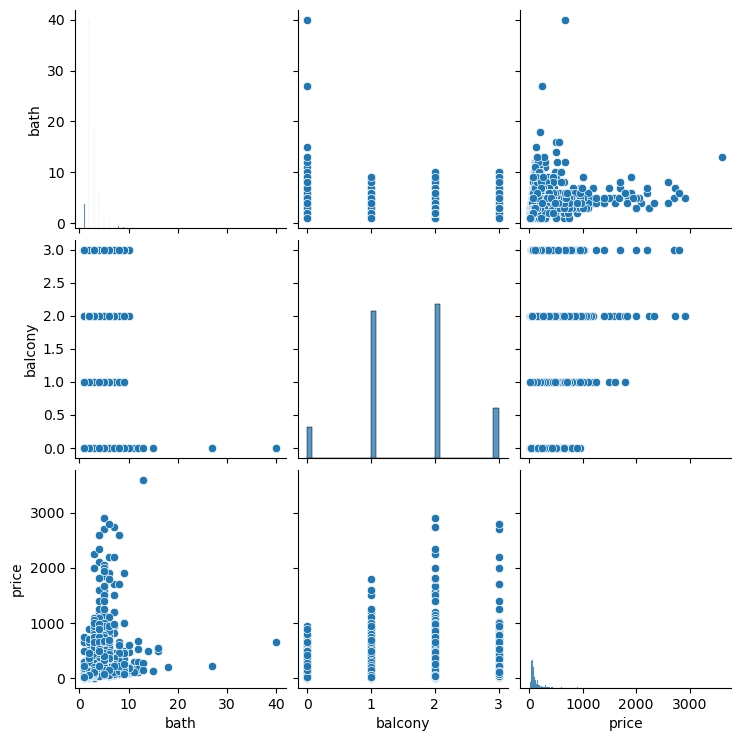

In [109]:
sns.pairplot(data_raw)

In [110]:
data_raw.isna().sum()

area_type          0
availability       0
location           1
size              16
society         5502
total_sqft         0
bath              73
balcony          609
price              0
dtype: int64

In [111]:
data_raw = data_raw.dropna(subset=['location','size','bath'])


In [112]:
data_raw = data_raw.drop('society', axis = 1)

In [113]:
data_raw = data_raw.fillna({'balcony': data_raw['balcony'].mean()})

In [114]:
def conver_total_to_float(x):
    if '-' in x:
        nums = x.split('-')
        return (float(nums[0]) + float(nums[1]))/2
    elif re.search(r'[a-zA-Z]', x):
        return np.nan
    else:
        return float(x)
    
data_raw['total_sqft'] = data_raw['total_sqft'].apply(conver_total_to_float)

In [115]:
size_int = []
for str_val in data_raw['size']:
    x = str_val.split(' ')
    size_int.append(float(x[0]))
data_raw['bhk'] = size_int

<Axes: xlabel='total_sqft'>

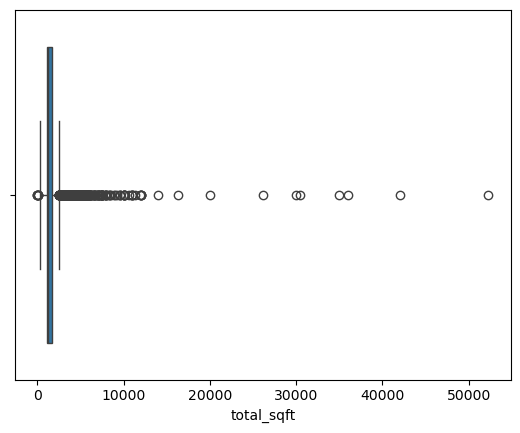

In [116]:
sns.boxplot(x =data_raw['total_sqft'])

In [117]:
data_raw = data_raw[data_raw['total_sqft'] / data_raw['bhk']<= 350]
data_raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1131 entries, 9 to 13311
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   area_type     1131 non-null   object 
 1   availability  1131 non-null   object 
 2   location      1131 non-null   object 
 3   size          1131 non-null   object 
 4   total_sqft    1131 non-null   float64
 5   bath          1131 non-null   float64
 6   balcony       1131 non-null   float64
 7   price         1131 non-null   float64
 8   bhk           1131 non-null   float64
dtypes: float64(5), object(4)
memory usage: 88.4+ KB


In [118]:
data_raw['price_per_sqft'] = data_raw['price'] / data_raw['total_sqft']

# Bài tập bổ sung (homework)


Bài tập 0: Sử dụng sns.boxplot() để quan sát đặc điểm phân bố dữ liệu của các trường số, mỗi trường này có outlier ko?

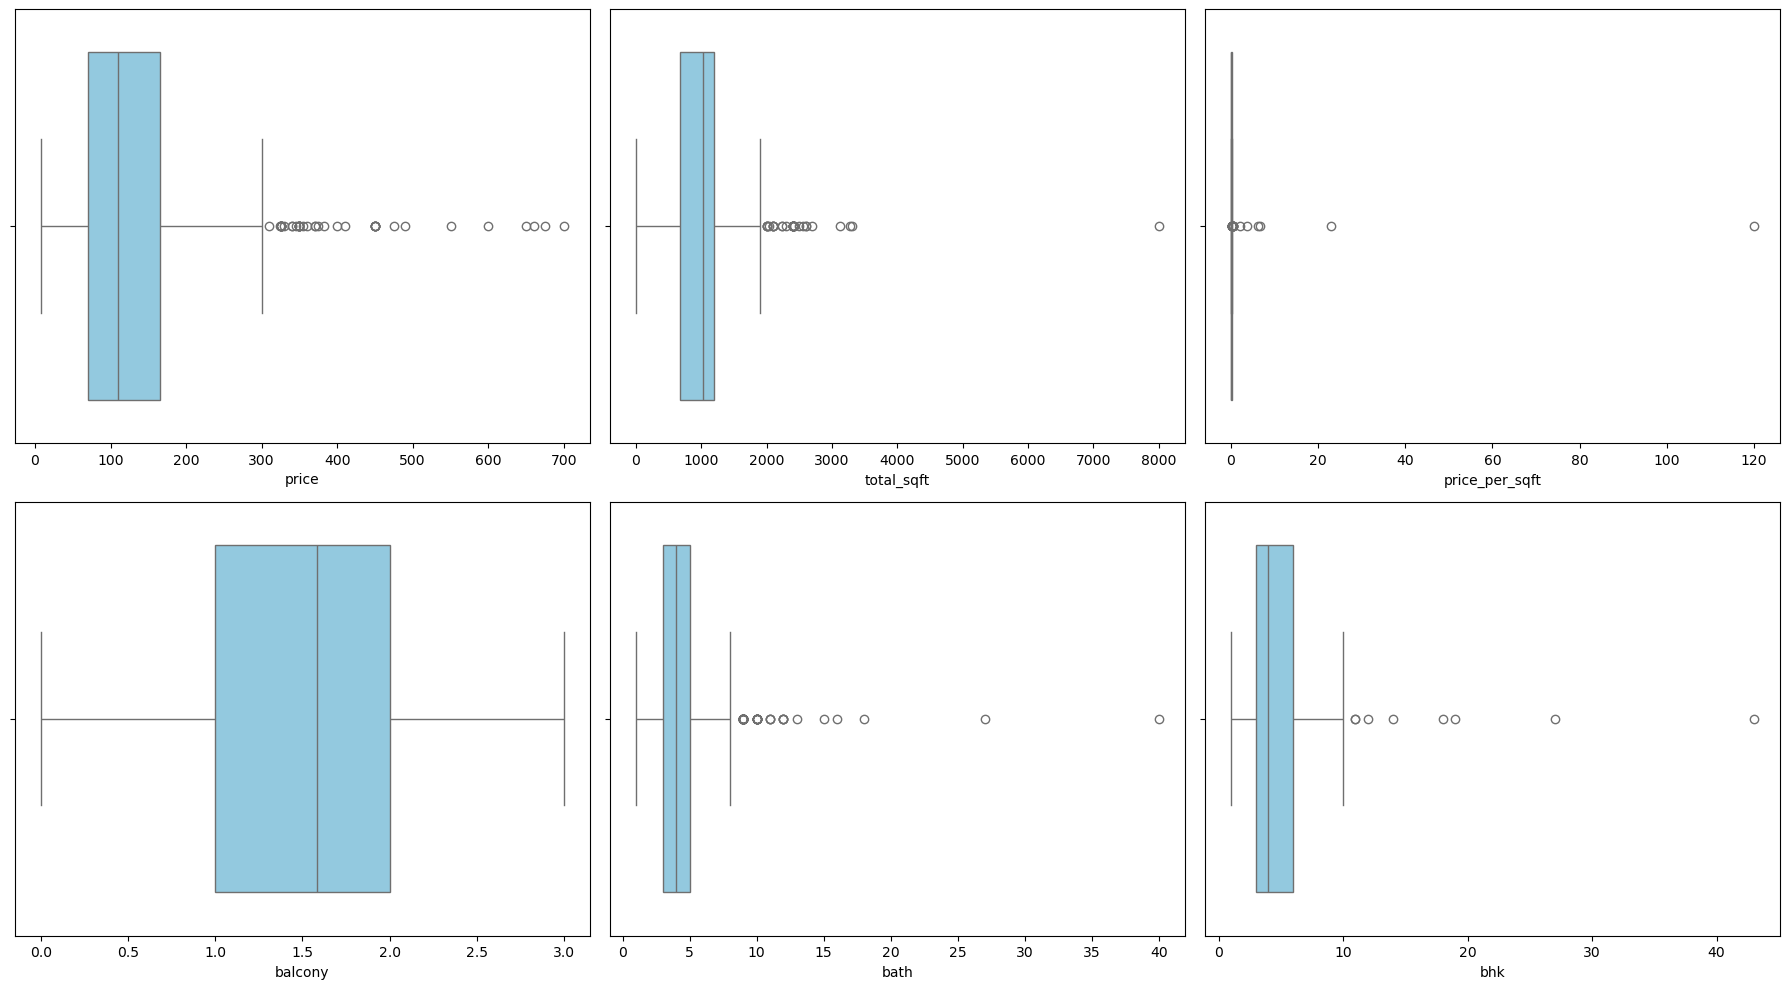

In [119]:
df = data_raw

vars = ['price', 'total_sqft', 'price_per_sqft', 'balcony', 'bath', 'bhk']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for i,var in enumerate(vars):  
    sns.boxplot(x = df[var], ax = axes.flatten()[i], color='skyblue')
plt.tight_layout()
plt.show()


Bài tập 1: Viết hàm bỏ đi các điểm dữ liệu có price per sqft dựa trên mean, std của các ngôi nhà dựa trên từng vị trí

> Gợi ý: Xét trên từng vị trí (location), ngôi nhà thỏa mãn phải có $price\_per\_sqft \in [mean - std, mean + std]$

In [120]:
def remove_price_per_sqft(df):
    df_out = pd.DataFrame()
    for key, subdf in df.groupby('location'):
        m = np.mean(subdf['price_per_sqft'])
        std = np.std(subdf['price_per_sqft'])
        reduced_df = subdf[(subdf['price_per_sqft'] >= (m-std)) & (subdf['price_per_sqft'] <= (m+std))]
        df_out = pd.concat([df_out,reduced_df], ignore_index= True)
    return df_out
df = remove_price_per_sqft(df= df)

Bài tập 2: Loại bỏ outlier xét theo trường bkh (số phòng)

Xét theo từng khu vực địa lí và theo từng loại nhà với số lượng phòng khác nhau, có một số ngôi nhà có giá không hợp lí (outliers), hãy tìm cách loại bỏ các outlier này. Cần ghi rõ quy tắc ghi nhận outlier

In [121]:
#Loại bỏ tất cả các căn có nhiều hơn 10 phòng




Bài tập 3: Loại bỏ outlier khi xét trường 'bathroom'

In [122]:
df = df[df['bath'] < df['bhk'] + 2]

Bài tập 4: Xem xét bỏ đi các trường không cần thiết

Gợi ý: bỏ đi ['area_type', 'availability',"location","size","total_sqft"]

In [ ]:
df = df.drop(['area_type','availability','size','total_sqft'], axis = 1)


In [133]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 844 entries, 0 to 860
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   location        844 non-null    object 
 1   bath            844 non-null    float64
 2   balcony         844 non-null    float64
 3   price           844 non-null    float64
 4   bhk             844 non-null    float64
 5   price_per_sqft  844 non-null    float64
dtypes: float64(5), object(1)
memory usage: 46.2+ KB


In [131]:
df['location'].value_counts()

location
Electronic City         18
Kanakpura Road          18
Nagarbhavi              16
Vidyaranyapura          11
Ramamurthy Nagar        11
                        ..
Govindapura              1
Goraguntepalya           1
Gollarahatti             1
Gokula Extension         1
white field,kadugodi     1
Name: count, Length: 498, dtype: int64

Bài tập 5*: Viết hàm trực quan hóa thể hiện mối tương quan giữa tổng diện tích (total_sqft) và giá nhà (price) theo từng vị trí địa lí (location) (tùy chọn minh họa theo 2 vị trí nào đó), của những căn nhà có 2 hoặc 3 phòng. Và cần phân biệt rõ điểm dữ liệu nào tương ứng với nhà có 2 phòng, điểm nào tương ứng với nhà có 3 phòng?


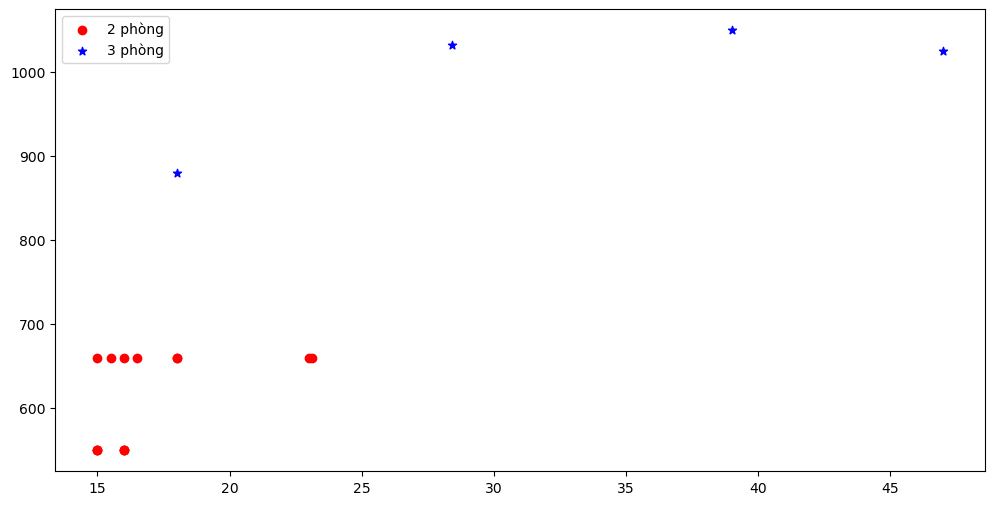

In [141]:
#Chọn khu vực nào đó tuyf ý
def Visualization(df, location):
    X_2 = df[(df['location'] == location) & (df['bhk'] == 2)]
    X_3 = df[(df['location'] == location) & (df['bhk'] == 3)]
    plt.figure(figsize=(12,6))
    plt.scatter(y = X_2['total_sqft'], x = X_2['price'], color ='red',marker='o',label = '2 phòng')
    plt.scatter(y = X_3['total_sqft'], x = X_3['price'], color ='blue',marker='*',label = '3 phòng')
    plt.legend()
    plt.show()
Visualization(df= data_raw,location='Electronic City')

Bài tập 6*: Thực hiện các câu lệnh để trả lời các câu hỏi dưới đây:

* Thống kê giá nhà theo từng loại khu vực (area_type). Làm với df9:
* xem xét theo từng khu vực, thì giá nhà trung bình (price_per_sqft) là bao nhiêu, tương quan về giá nhà trung bình giữa các khu vực

* Gợi ý: Phần này có thể đưa ra kết quả dạng bảng hoặc biểu đồ (cột, histogram, ...). 
 - Sử dụng các lệnh: df.groupby(), df.sortvalues(), ... để trích xuất giá trị
 - Sử dụng matplotlib: plt.bar(), ...


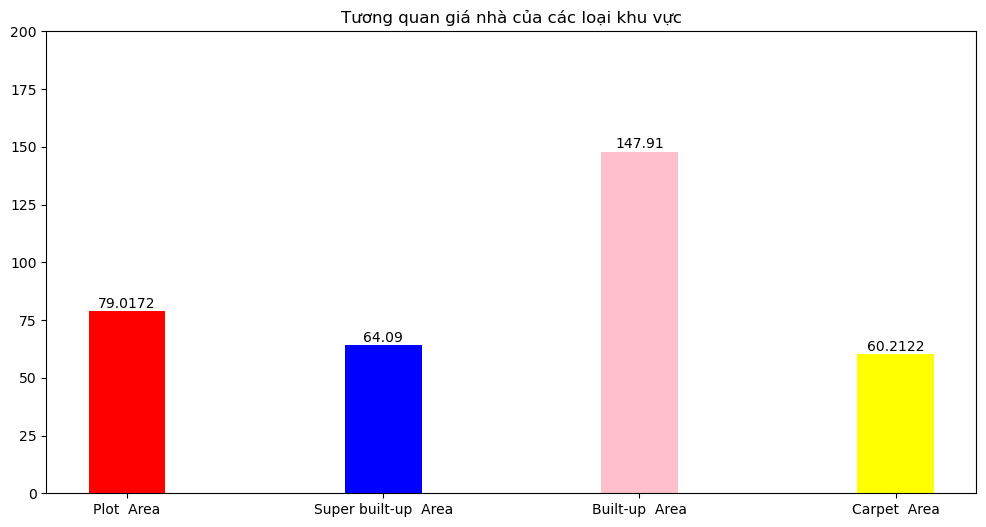

In [ ]:
data_mean = data_raw.groupby('area_type')['price'].mean()
plt.figure(figsize = (12,6))
bars =  plt.bar(x = data_raw['area_type'].unique(), height = data_mean,
        width = 0.3, color = ['red','blue','pink','yellow'],)
plt.bar_label(container=bars, padding=3)
plt.title('Tương quan giá nhà của các loại khu vực')
plt.ylim(0,200)
plt.show()